In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
sys.path.append(os.path.abspath("src"))
from wAMEs.temporal_dynamics import integrate_I_traj_kernel
from wAMEs.plotting import get_plot_style, make_truncated_colormap, apply_axis_style
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from wAMEs.core import load_group_statistics

# Load group statistics
network = "CNS"
gm, pn, mmax, nmax, pmax, state_meta = load_group_statistics(
    network,
    path="Data/group_statistics.txt",
)

nu = 9.5
mu = 1.0
w = 5.0
lam_kernel = 2e-3   # define here — currently missing, Cell 3 will NameError
scale = w           

# Output directory
save_dir = "Files"
os.makedirs(save_dir, exist_ok=True)

In [10]:
def w_allegiance(n, i, scale):
    """Nodes flee diverse groups — prefer homogeneous ones (allegiance/homophily).
    Rate peaks at phi=0.5 and is zero at the homogeneous extremes (phi=0 or 1)."""
    phi = i / n
    print(f"n={n}, i={i}, phi={phi}, w_allegiance={scale * 4 * phi * (1 - phi)}")
    return scale * 4 * phi * (1 - phi)


Max trajectory deviation: 7.73e-01
Pass (atol=1e-10): False


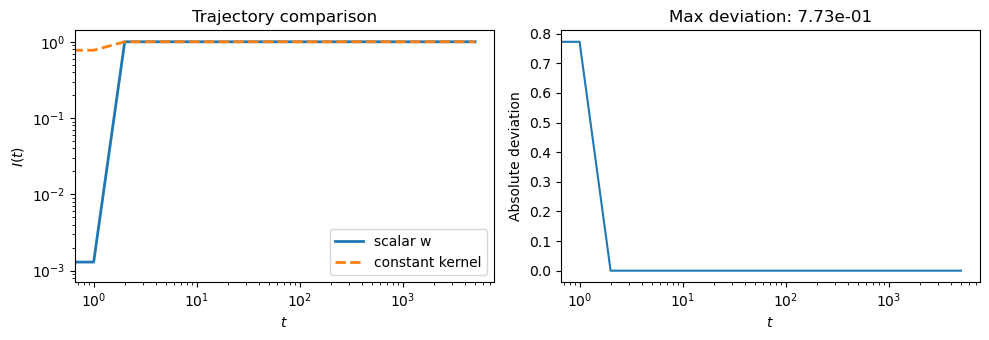

In [4]:
# --- Scalar limit verification ---
# A constant kernel w(n,i) = scale must reproduce integrate_I_traj exactly.
# Max deviation at machine precision (~1e-14) confirms S_w is correct.
# Larger deviation means the pnmat weighting in S_w is wrong.

from wAMEs.temporal_dynamics import integrate_I_traj

test_I0 = 1e-3
test_lam = lam_kernel  # 2e-3
test_traj_points = 5000  # coarse — just need trajectory shape, not resolution

# Scalar baseline
t_scalar, I_scalar = integrate_I_traj(
    lam=test_lam,
    state_meta=state_meta,
    nmax=nmax,
    mmax=mmax,
    gm=gm,
    mu=mu,
    w=scale,       # w=5.0, same as scale
    nu=nu,
    I0=test_I0,
    traj_points=test_traj_points,
)

# Constant kernel — should be identical if S_w reduces correctly to I
t_kernel, I_kernel, fni_kernel = integrate_I_traj_kernel(
    lam=test_lam,
    w_func=lambda n, i, s: s,   # constant: w(n,i) = scale
    w_args=(scale,),
    state_meta=state_meta,
    nmax=nmax,
    mmax=mmax,
    gm=gm,
    mu=mu,
    nu=nu,
    I0=test_I0,
    traj_points=test_traj_points,
)

max_dev = np.max(np.abs(I_scalar - I_kernel))
print(f"Max trajectory deviation: {max_dev:.2e}")
print(f"Pass (atol=1e-10): {np.allclose(I_scalar, I_kernel, atol=1e-10)}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].plot(t_scalar, I_scalar, label="scalar w", lw=2)
axes[0].plot(t_kernel, I_kernel, "--", label="constant kernel", lw=2)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel(r"$t$")
axes[0].set_ylabel(r"$I(t)$")
axes[0].set_title("Trajectory comparison")
axes[0].legend()

axes[1].plot(t_scalar, np.abs(I_scalar - I_kernel))
axes[1].set_xscale("log")
axes[1].set_xlabel(r"$t$")
axes[1].set_ylabel("Absolute deviation")
axes[1].set_title(f"Max deviation: {max_dev:.2e}")

plt.tight_layout()
plt.show()

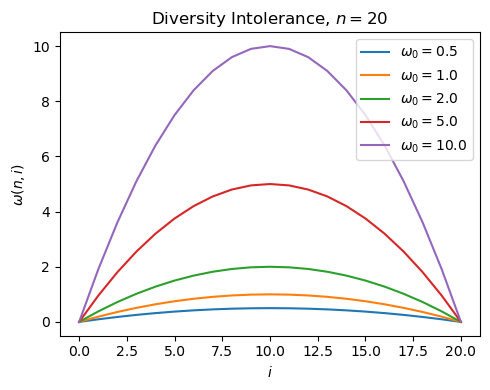

In [5]:
n = nmax  # e.g. nmax for Thiers13
i_vals = np.arange(0, n+1)
scales = [0.5, 1.0, 2.0, 5.0, 10.0]

fig, ax = plt.subplots(figsize=(5, 4))

for scale in scales:
    w_vals = [w_allegiance(n, i, scale) for i in i_vals]
    ax.plot(i_vals, w_vals, label=rf"$\omega_0={scale}$")

ax.set_xlabel(r"$i$")
ax.set_ylabel(r"$\omega(n,i)$")
ax.set_title(rf"Diversity Intolerance, $n={n}$")
ax.legend()
plt.tight_layout()
plt.savefig("src/wAMEs/figures/allegiance_kernel.png", dpi=300)
plt.show()

Running trajectory integration with allegiance kernel (scale=5.0)...
n=2, i=0, phi=0.0, w_allegiance=0.0
n=2, i=1, phi=0.5, w_allegiance=5.0
n=2, i=2, phi=1.0, w_allegiance=0.0
n=3, i=0, phi=0.0, w_allegiance=0.0
n=3, i=1, phi=0.3333333333333333, w_allegiance=4.444444444444445
n=3, i=2, phi=0.6666666666666666, w_allegiance=4.444444444444445
n=3, i=3, phi=1.0, w_allegiance=0.0
n=4, i=0, phi=0.0, w_allegiance=0.0
n=4, i=1, phi=0.25, w_allegiance=3.75
n=4, i=2, phi=0.5, w_allegiance=5.0
n=4, i=3, phi=0.75, w_allegiance=3.75
n=4, i=4, phi=1.0, w_allegiance=0.0
n=5, i=0, phi=0.0, w_allegiance=0.0
n=5, i=1, phi=0.2, w_allegiance=3.2
n=5, i=2, phi=0.4, w_allegiance=4.8
n=5, i=3, phi=0.6, w_allegiance=4.800000000000001
n=5, i=4, phi=0.8, w_allegiance=3.1999999999999993
n=5, i=5, phi=1.0, w_allegiance=0.0
n=6, i=0, phi=0.0, w_allegiance=0.0
n=6, i=1, phi=0.16666666666666666, w_allegiance=2.7777777777777777
n=6, i=2, phi=0.3333333333333333, w_allegiance=4.444444444444445
n=6, i=3, phi=0.5, w_all

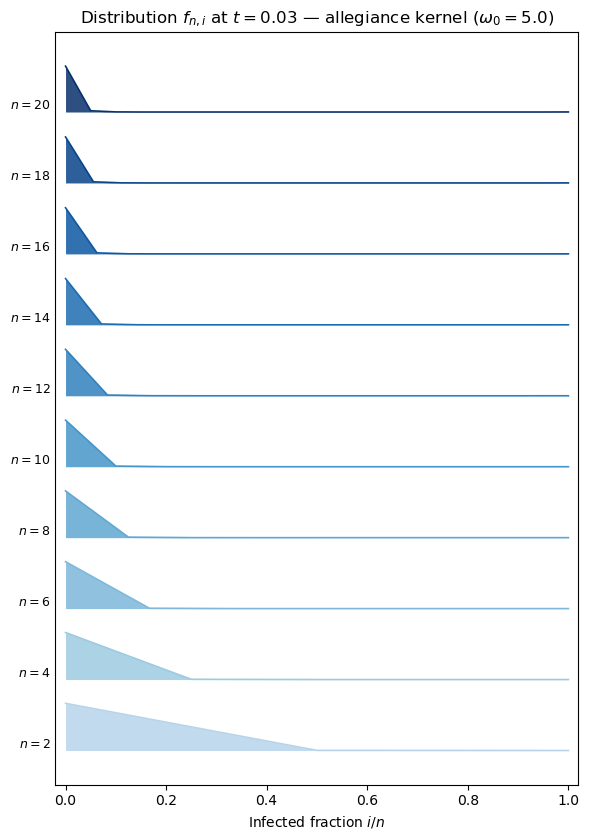

In [17]:
# Distribution of group states across n values at a single time snapshot
# Ridgeline style matching example_dist.png
I0 = 1e-3
traj_points = 5000
t_max = 20.0
scale = 5.0  # w=5.0, same as scale
print(f"Running trajectory integration with allegiance kernel (scale={scale})...")
t_all, I_all, fni_traj = integrate_I_traj_kernel(
    lam=lam_kernel,
    w_func=w_allegiance,
    w_args=(scale,),
    state_meta=state_meta,
    nmax=nmax,
    mmax=mmax,
    gm=gm,
    mu=mu,
    nu=nu,
    I0=I0,
    traj_points=traj_points,
    t_max=t_max,
)

# Pick a snapshot — change index to explore different moments in the transient
log_snaps = np.logspace(np.log10(t_all[1]), np.log10(t_all[-1]), 5)
snap_indices = [np.argmin(np.abs(t_all - ts)) for ts in log_snaps]
tidx = snap_indices[1]   # middle snapshot is 2; try [1] or [3]
t_snap = t_all[tidx]

# n values to display — every other size from 2 to nmax
n_show = list(range(2, nmax + 1, max(1, nmax // 8)))
if nmax not in n_show:
    n_show.append(nmax)
n_show = sorted(n_show)

spacing = 1.5
cmap = plt.get_cmap("Blues")
colors = [cmap(0.3 + 0.7 * k / max(len(n_show) - 1, 1)) for k in range(len(n_show))]

fig, ax = plt.subplots(figsize=(6, len(n_show) * 0.7 + 1.5))

for k, n0 in enumerate(n_show):
    phi_vals = np.arange(n0 + 1) / n0
    dist = fni_traj[tidx, n0, :n0 + 1].copy()
    total = dist.sum()
    if total > 1e-14:
        dist /= total
    baseline = k * spacing
    ax.fill_between(phi_vals, baseline, baseline + dist,
                    alpha=0.85, color=colors[k], linewidth=0)
    ax.plot(phi_vals, baseline + dist, color=colors[k], lw=1.2)
    ax.text(-0.03, baseline, rf"$n={n0}$", ha="right", va="bottom", fontsize=9)

ax.set_xlabel(r"Infected fraction $i/n$")
ax.set_yticks([])
ax.set_xlim(-0.02, 1.02)
ax.set_title(rf"Distribution $f_{{n,i}}$ at $t={t_snap:.2f}$ — allegiance kernel ($\omega_0={scale}$)")
plt.tight_layout()
plt.savefig("src/wAMEs/figures/group_state_ridgeline.png", dpi=300)
plt.show()